In [1]:
%reset -f
from cProfile import label
from email import message_from_binary_file
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from IPython.core.pylabtools import figsize
from spyder_kernels.utils.lazymodules import pandas

pv.set_jupyter_backend('static')

from pyqtgraph import plots


In [2]:
def GetInfo(filePath):
    import h5py
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

In [3]:
import h5py
from concurrent.futures import ThreadPoolExecutor

def process_folder(folder, data):
    subVal = {}
    for table in data[folder]:
        subsubVal = {field: data[folder][table][field] for field in data[folder][table].dtype.fields.keys()}
        subVal[table] = subsubVal
    return folder, subVal

def GetInfoM(filePath):
    All = {}
    with h5py.File(filePath, "r") as f:
        data = {folder: {table: f[folder][table][:] for table in f[folder]} for folder in f}
        with ThreadPoolExecutor(max_workers=20) as executor:
            results = list(executor.map(lambda folder: process_folder(folder, data), data.keys()))
        All = dict(results)
    return All

In [4]:
### Get all
import os
folder="NEXTCRAB_Debug"
files=os.listdir(f"/tmp/argon/opticks/GEOM/{folder}/nexus/ALL0/")

Hits={}
Steps={}
Records={}
Photons={}
GenStep={}
All=sorted(files)[:-2]
print (f" All the event files {All}")
Count=0
for i in All:
    record=np.load(f"/tmp/argon/opticks/GEOM/{folder}/nexus/ALL0/{i}/record.npy")
    photon=np.load(f"/tmp/argon/opticks/GEOM/{folder}/nexus/ALL0/{i}/photon.npy")
    hit=np.load(f"/tmp/argon/opticks/GEOM/{folder}/nexus/ALL0/{i}/hit.npy")
    #seq=np.load(f"/tmp/argon/opticks/GEOM/{older}/nexus/ALL0/{i}/seq.npy")
    gen=np.load(f"/tmp/argon/opticks/GEOM/{folder}/nexus/ALL0/{i}/genstep.npy")
    Hits[Count]=hit
    Records[Count]=record
    Photons[Count]=photon
    GenStep[Count]=gen
    Steps[Count]=record[:,0,0,:3] ## Position and time of first 5 steps
    Count=Count+1



 All the event files ['A000', 'A001']


In [5]:
#Conversions
boundary_  = lambda p:p.view(np.uint32) >> 16    
flag_      = lambda p:p.view(np.uint32) & 0xffff

identity_ = lambda p:p.view(np.uint32)[3,1]   
primIdx_   = lambda p:identity_(p) >> 16  
instanceId_  = lambda p:identity_(p) & 0xffff  

idx_      = lambda p:p.view(np.uint32)[3,2] & 0x7fffffff
orient_   = lambda p:p.view(np.uint32)[3,2] >> 31

flagmask_ = lambda p:p.view(np.uint32)


class PhotonFlag:
    CERENKOV = 1 << 0
    SCINTILLATION = 1 << 1
    MISS = 1 << 2
    BULK_ABSORB = 1 << 3
    BULK_REEMIT = 1 << 4
    BULK_SCATTER = 1 << 5
    SURFACE_DETECT = 1 << 6
    SURFACE_ABSORB = 1 << 7
    SURFACE_DREFLECT = 1 << 8
    SURFACE_SREFLECT = 1 << 9
    BOUNDARY_REFLECT = 1 << 10
    BOUNDARY_TRANSMIT = 1 << 11
    TORCH = 1 << 12
    NAN_ABORT = 1 << 13
    EFFICIENCY_CULL = 1 << 14
    EFFICIENCY_COLLECT = 1 << 15
    __NATURAL = 1 << 16
    __MACHINERY = 1 << 17
    __EMITSOURCE = 1 << 18
    PRIMARYSOURCE = 1 << 19
    GENSTEPSOURCE = 1 << 20
    DEFER_FSTRACKINFO = 1 << 21
    
class PhotonFlagNames:
    ZERO = "."
    CERENKOV = "CERENKOV"
    SCINTILLATION = "SCINTILLATION"
    TORCH = "TORCH"
    MISS = "MISS"
    BULK_ABSORB = "BULK_ABSORB"
    BULK_REEMIT = "BULK_REEMIT"
    BULK_SCATTER = "BULK_SCATTER"
    SURFACE_DETECT = "SURFACE_DETECT"
    SURFACE_ABSORB = "SURFACE_ABSORB"
    SURFACE_DREFLECT = "SURFACE_DREFLECT"
    SURFACE_SREFLECT = "SURFACE_SREFLECT"
    BOUNDARY_REFLECT = "BOUNDARY_REFLECT"
    BOUNDARY_TRANSMIT = "BOUNDARY_TRANSMIT"
    NAN_ABORT = "NAN_ABORT"
    EFFICIENCY_CULL = "EFFICIENCY_CULL"
    EFFICIENCY_COLLECT = "EFFICIENCY_COLLECT"
    BAD_FLAG = "BAD_FLAG"
    DEFER_FSTRACKINFO = "DEFER_FSTRACKINFO"

def GetFlag(flag):
    particle_event_types = {
        0: PhotonFlagNames.ZERO,
        PhotonFlag.CERENKOV: PhotonFlagNames.CERENKOV,
        PhotonFlag.SCINTILLATION: PhotonFlagNames.SCINTILLATION,
        PhotonFlag.MISS: PhotonFlagNames.MISS,
        PhotonFlag.BULK_ABSORB: PhotonFlagNames.BULK_ABSORB,
        PhotonFlag.BULK_REEMIT: PhotonFlagNames.BULK_REEMIT,
        PhotonFlag.BULK_SCATTER: PhotonFlagNames.BULK_SCATTER,
        PhotonFlag.SURFACE_DETECT: PhotonFlagNames.SURFACE_DETECT,
        PhotonFlag.SURFACE_ABSORB: PhotonFlagNames.SURFACE_ABSORB,
        PhotonFlag.SURFACE_DREFLECT: PhotonFlagNames.SURFACE_DREFLECT,
        PhotonFlag.SURFACE_SREFLECT: PhotonFlagNames.SURFACE_SREFLECT,
        PhotonFlag.BOUNDARY_REFLECT: PhotonFlagNames.BOUNDARY_REFLECT,
        PhotonFlag.BOUNDARY_TRANSMIT: PhotonFlagNames.BOUNDARY_TRANSMIT,
        PhotonFlag.TORCH: PhotonFlagNames.TORCH,
        PhotonFlag.NAN_ABORT: PhotonFlagNames.NAN_ABORT,
        PhotonFlag.EFFICIENCY_COLLECT: PhotonFlagNames.EFFICIENCY_COLLECT,
        PhotonFlag.EFFICIENCY_CULL: PhotonFlagNames.EFFICIENCY_CULL,
        PhotonFlag.DEFER_FSTRACKINFO: PhotonFlagNames.DEFER_FSTRACKINFO
    }
    if(flag in particle_event_types):
        return particle_event_types[flag]
    else:
        return particle_event_types.get(flag, PhotonFlagNames.BAD_FLAG)
    

In [6]:
def GetPhotonsPositionsFromRecord(Rec,Event,Mask):
    xR=Rec[Event][:,:,0,0].ravel()[Mask]
    yR=Rec[Event][:,:,0,1].ravel()[Mask]
    zR=Rec[Event][:,:,0,2].ravel()[Mask]

    return np.stack((xR.reshape(-1),yR.reshape(-1),zR.reshape(-1)),axis=1)


['.' 'BOUNDARY_REFLECT' 'BOUNDARY_TRANSMIT' 'SCINTILLATION'
 'SURFACE_ABSORB' 'SURFACE_DETECT' 'SURFACE_SREFLECT']
[ 5 15 17 ... 13  5 22] 31813760
['SURFACE_ABSORB' 'SURFACE_ABSORB' 'SURFACE_ABSORB' ... 'SURFACE_ABSORB'
 'SURFACE_ABSORB' 'SURFACE_ABSORB'] 31813760
[ -9.994571 -36.49864  -37.400898 ...   0.         0.         0.      ] 31813760


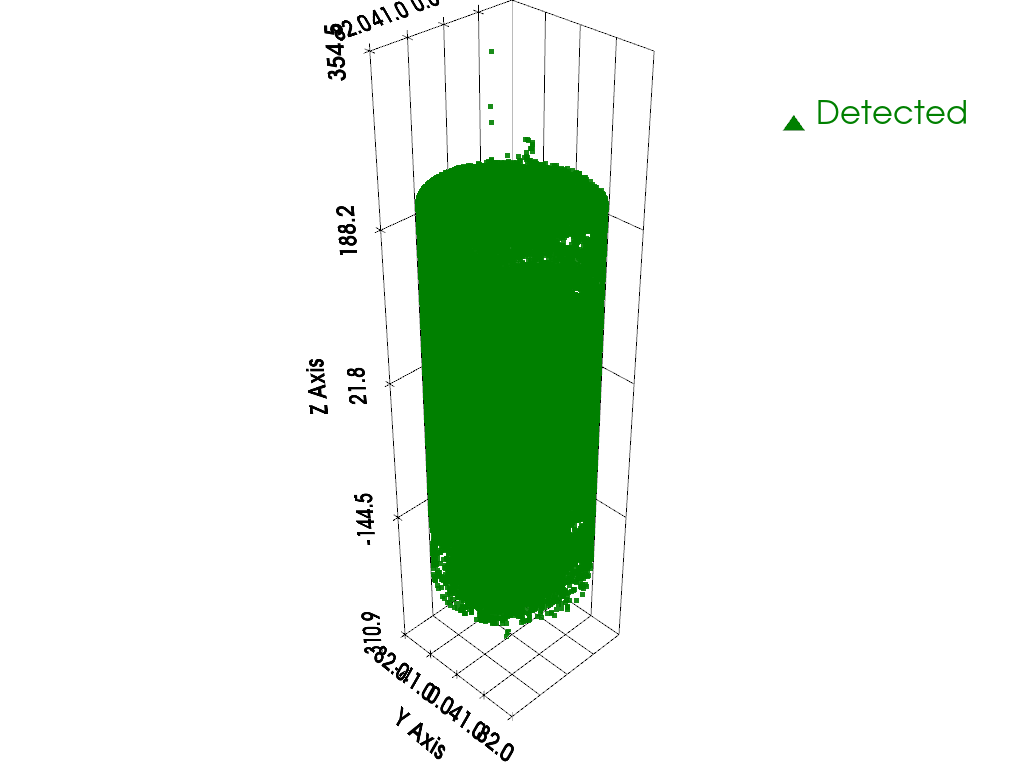

<Figure size 2500x2500 with 0 Axes>

In [7]:
### Record Photon
## NumPhoton,boundaries,properties(position,momentum),(x,y,z,t)

import seaborn as sns
Event=0
Flags=Records[Event][:,:,3,0]
recPhotons=Records[Event][:,:,0,:3]

Boundaries=np.array(boundary_(Records[0][:,:,3,0])).ravel() 
GetFlagVector=np.vectorize(GetFlag)
FLg=GetFlagVector(flag_(Flags)).ravel()

#ZeroMask=(FLg!= PhotonFlagNames.ZERO) & (FLg != PhotonFlagNames.MISS) & (FLg != PhotonFlagNames.SCINTILLATION) & (FLg != PhotonFlagNames.NAN_ABORT)
#FLg=FLg[ZeroMask]
#Boundaries=Boundaries[ZeroMask]
BoundaryMask=FLg== (PhotonFlagNames.SURFACE_ABSORB) 
TransitPhotons=GetPhotonsPositionsFromRecord(Records,Event,BoundaryMask)
DetectedPhotonsMask=FLg== (PhotonFlagNames.SURFACE_DETECT)
DetectedPhotons=GetPhotonsPositionsFromRecord(Records,Event,BoundaryMask)

print(np.unique(FLg))
print(Boundaries[BoundaryMask],len(Boundaries))
print(FLg[BoundaryMask],len(Boundaries))
print(Records[Event][:,:,0,0].ravel(),len(Records[Event][:,:,0,0].ravel()))


Dict={"Flags":FLg[BoundaryMask],"Bnd":Boundaries[BoundaryMask]}
plt.figure(figsize=(25,25))
#sns.boxplot(data=Dict,x="Flags",y="Bnd",hue="Flags",whis=(0,100))

pl=pv.Plotter()
#pl.add_mesh(TransitPhotons,color="red",opacity=0.9,label="Photons Pass Through")
pl.add_mesh(DetectedPhotons,color="green",opacity=0.9,label="Detected")

    
pl.add_legend()     
pl.show_grid()

pl.show()

del pl


In [8]:
## Related to Photons
Event=0
xphoton = Photons[Event][:,0,0]
yphoton = Photons[Event][:,0,1]
zphoton = Photons[Event][:,0,2]
tphoton = Photons[Event][:,0,3]
momx = Photons[Event][:,1,0]
momy = Photons[Event][:,1,1]
momz = Photons[Event][:,1,2]
iindex = Photons[Event][:,1,3]
polx = Photons[Event][:,2,0]
poly = Photons[Event][:,2,1]
polz = Photons[Event][:,2,2]
wavelength = Photons[Event][:,2,3]
boundary_flag=Photons[Event][:,3,0]
identity=Photons[Event][:,3,1]
orientidx=Photons[Event][:,3,2]
flagmask=Photons[Event][:,3,0]
GetFlagVector=np.vectorize(GetFlag)
print(GetFlagVector(flag_(flagmask)))
print(boundary_(flagmask))
## Related to Photons

['SURFACE_ABSORB' 'SURFACE_ABSORB' 'SURFACE_ABSORB' ... 'SURFACE_ABSORB'
 'SURFACE_ABSORB' 'SURFACE_ABSORB']
[ 5 15 17 ... 13  5 22]


In [9]:
Flags=Records[Event][:,:,3,0]
FLg=GetFlagVector(flag_(Flags)).ravel()

In [10]:

PhMask=(FLg==(PhotonFlagNames.SURFACE_DETECT))
zR=Records[Event][:,:,0,2].ravel()[PhMask]
Zmaks=zR<0

In [11]:
print(FLg[PhMask][Zmaks])

['SURFACE_DETECT' 'SURFACE_DETECT' 'SURFACE_DETECT' ... 'SURFACE_DETECT'
 'SURFACE_DETECT' 'SURFACE_DETECT']


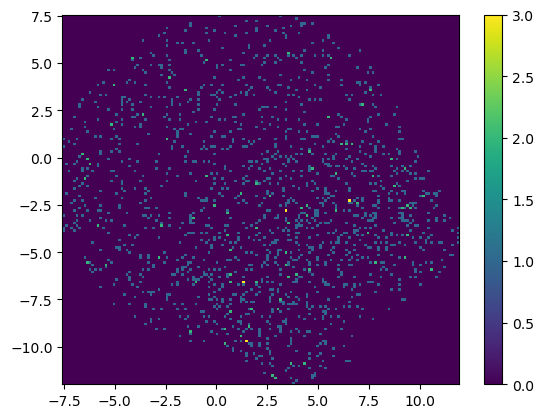

In [12]:

xR=Records[Event][:,:,0,0].ravel()[PhMask][Zmaks]
yR=Records[Event][:,:,0,1].ravel()[PhMask][Zmaks]

_=plt.hist2d(xR,yR,bins=150)
#plt.xlim(-10,10)
#plt.ylim(-10,10)
plt.colorbar()

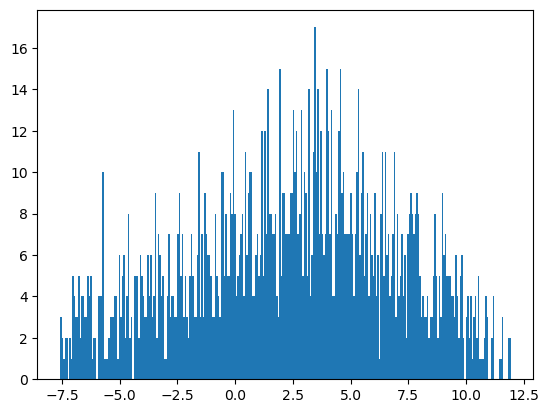

In [13]:
_=plt.hist(xR,bins=300)


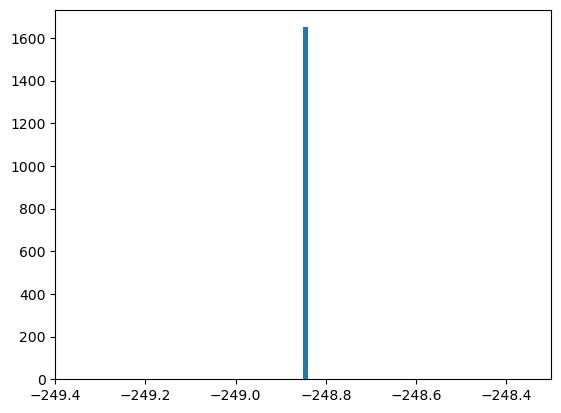

In [14]:
_=plt.hist(zR[Zmaks],bins=100)


In [ ]:
plt.hist2d(xphoton,yphoton,bins=600,cmin=0,cmax=2000)
plt.xlim(-100,100)
#plt.ylim(-222.9,-270)
plt.colorbar()

In [16]:
len(zphoton[(zphoton>-260) & (zphoton<-220)])

1711

In [17]:
## Related to Photons
Event=0
xhit = Hits[Event][:,0,0]
yhit = Hits[Event][:,0,1]
zhit = Hits[Event][:,0,2]
thit = Hits[Event][:,0,3]
momx_hit = Hits[Event][:,1,0]
momy_hit = Hits[Event][:,1,1]
momz_hit = Hits[Event][:,1,2]
iindex_hit = Hits[Event][:,1,3]
polx_hit = Hits[Event][:,2,0]
poly_hit = Hits[Event][:,2,1]
polz_hit = Hits[Event][:,2,2]
wavelength_hit = Hits[Event][:,2,3]
boundary_flag_hit=boundary_(Hits[Event][:,3,0])
identity_hit=Hits[Event][:,3,1]
orientidx_hit=Hits[Event][:,3,2]
flagmask_hit=Hits[Event][:,3,3]

In [18]:


def GetHits(h,bnd=[31,30]):
    All={}
    PMT={}
    Cam={}
    CameraHits=np.array([])
    PMTHits=np.array([])
    Xall_Cam,Yall_Cam,Zall_Cam,Tall_Cam=np.array([]),np.array([]),np.array([]),np.array([])
    Xall_Pmt,Yall_Pmt,Zall_Pmt,Tall_Pmt=np.array([]),np.array([]),np.array([]),np.array([])

    Wavelength_Cam,Wavelength_Pmt=np.array([]),np.array([])
    print(list(h.keys()))
    for Event in list(h.keys()):
        zhit = h[Event][:,0,2]
        CamMask=zhit>0
        PMTMask=zhit<0
        print(PMTMask)
        xhit = h[Event][:,0,0]
        yhit = h[Event][:,0,1]
        zhit = h[Event][:,0,2]
        thit = h[Event][:,0,3]
        momx_hit = h[Event][:,1,0]
        momy_hit = h[Event][:,1,1]
        momz_hit = h[Event][:,1,2]
        polx_hit = h[Event][:,2,0]
        poly_hit = h[Event][:,2,1]
        polz_hit = h[Event][:,2,2]
        wavelength_hit = h[Event][:,2,3]
        boundary_flag_hit=boundary_(h[Event][:,3,0])


        ## PMT
        PMT[Event]={"Pos":[xhit[PMTMask],yhit[PMTMask],zhit[PMTMask]],"thit":thit[PMTMask],"Mom":[momx_hit[PMTMask],momy_hit[PMTMask],momz_hit[PMTMask]],"Pol":[polx_hit[PMTMask],poly_hit[PMTMask],polz_hit[PMTMask]],"wavelength":wavelength_hit[PMTMask]}
        PMTHits=np.append(len(boundary_flag_hit[PMTMask]),PMTHits)
        Xall_Pmt=np.append(Xall_Pmt,xhit[PMTMask])
        Yall_Pmt=np.append(Yall_Pmt,yhit[PMTMask])
        Zall_Pmt=np.append(Zall_Pmt,zhit[PMTMask])
        Tall_Pmt=np.append(Tall_Pmt,thit[PMTMask])
        Wavelength_Pmt=np.append(Wavelength_Pmt,wavelength_hit[PMTMask])
        
        ## Camera
        Cam[Event]={"Pos":[xhit[CamMask],yhit[CamMask],zhit[CamMask]],"thit":thit[CamMask],"Mom":[momx_hit[CamMask],momy_hit[CamMask],momz_hit[CamMask]],"Pol":[polx_hit[CamMask],poly_hit[CamMask],polz_hit[CamMask]],"wavelength":wavelength_hit[CamMask]}
        CameraHits=np.append(len(boundary_flag_hit[CamMask]),CameraHits)
        Xall_Cam=np.append(Xall_Cam,xhit[CamMask])
        Yall_Cam=np.append(Yall_Cam,yhit[CamMask])
        Zall_Cam=np.append(Zall_Cam,zhit[CamMask])
        Tall_Cam=np.append(Tall_Cam,thit[CamMask])
        Wavelength_Cam=np.append(Wavelength_Cam,wavelength_hit[CamMask])

                
    Cam["Combined"]={"x":Xall_Cam,"y":Yall_Cam,"z":Zall_Cam,"t":Tall_Cam,"w":Wavelength_Cam}
    PMT["Combined"]={"x":Xall_Pmt,"y":Yall_Pmt,"z":Zall_Pmt,"t":Tall_Pmt,"w":Wavelength_Pmt}

    All={"CamHits":CameraHits,"PMTHits":PMTHits,"PMT":PMT,"Cam":Cam}
    return All

In [19]:
## Slow with Multi Processing 2s
#Hit_Organized=GetHitsM(Hits)

In [20]:
### For Record

## Related to Photons
xphoton = record[:,0,0]
yphoton = record[:,0,1]
zphoton = record[:,0,2]
tphoton = record[:,0,3]
momx = record[:,1,0]
momy = record[:,1,1]
momz = record[:,1,2]
iindex = record[:,1,3]
polx = record[:,2,0]
poly = record[:,2,1]
polz = record[:,2,2]
wavelength = record[:,2,3]
boundary_flag=record[:,3,0]
identity=record[:,3,1]
orientidx=record[:,3,2]
flagmask=record[:,3,3]

In [ ]:
#H5File=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/S1_test.h5")

In [21]:
## MultiProcessing
H5File=GetInfoM("/home/argon/Projects/Ilker/NewNexus/t.h5")


In [22]:
photonsMC=H5File["MC"]["particles"]
G4H5Hits=H5File["MC"]["GEANT4_Optical_Hits"]
OpticksH5Hits = H5File["MC"]["Opticks_Hits"]

## Masks
## Opticks

#OpticksPMTMask=(OpticksH5Hits['boundary']>29) | (OpticksH5Hits['boundary']==31)    ##PMT
#OpticksCamMask=(OpticksH5Hits['boundary']==27) | (OpticksH5Hits['boundary']==30)
OpticksPMTMask=(OpticksH5Hits['z']<100)    ##PMT
OpticksCamMask=(OpticksH5Hits['z'] > 200)  ##Camera

## Geant4
Geant4PMTMask=G4H5Hits['name']==b'PMTWindow' ##PMT
Geant4CamMask=G4H5Hits['name']==b'camWindow' ##Camera
bnd=[np.unique(OpticksH5Hits['boundary'][OpticksPMTMask]),np.unique(OpticksH5Hits['boundary'][OpticksCamMask])]
print(bnd)
if(len(bnd[0])>1 or len(bnd[1])>1):
    print("Boundary issue ")
    bnd=[bnd[0],bnd[1]]
# Pretty Fast < 10 ms 
#
#Hit_Organized = GetHits(Hits,bnd=bnd)

[array([31], dtype=uint32), array([29], dtype=uint32)]


In [23]:
arrayG4_initial=np.stack((photonsMC["initial_x"].reshape(-1),photonsMC["initial_y"].reshape(-1),photonsMC["initial_z"].reshape(-1)),axis=1)
arrayG4_final = np.stack(
    (photonsMC["final_x"].reshape(-1), photonsMC["final_y"].reshape(-1), photonsMC["final_z"].reshape(-1)),
    axis=1)

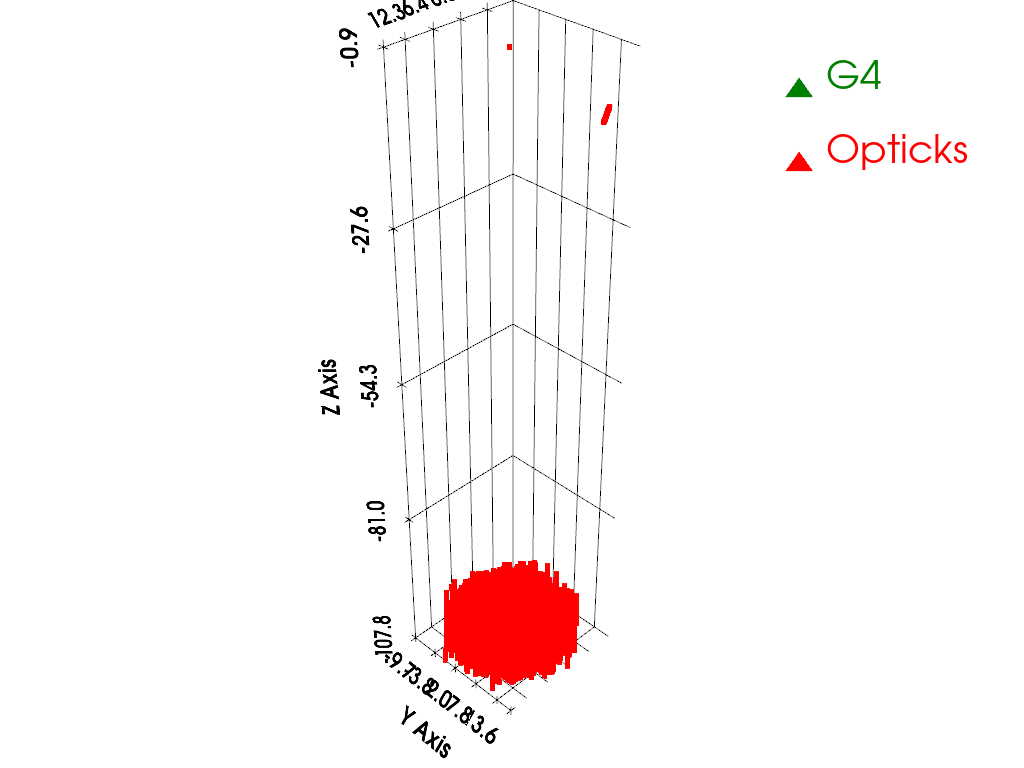

In [24]:
pl=pv.Plotter()
pl.add_mesh(arrayG4_initial,color="green",label="G4")

for key in Steps.keys():
    if(key==0):
        pl.add_mesh(Steps[key],color="red",opacity=0.9,label="Opticks")
    else:
        pl.add_mesh(Steps[key],color="red",opacity=0.9)
pl.add_legend()     
pl.show_grid()

pl.show()

del pl

In [25]:

#RecordTest = np.stack((X.reshape(-1), Y.reshape(-1), Z.reshape(-1)),axis=1)
RecordTest=record[:,0,0,:3]

In [26]:
X, Y, Z = [], [], []

for photon in Photons.values():
    X.extend(photon[:, 0, 0])
    Y.extend(photon[:, 0, 1])
    Z.extend(photon[:, 0, 2])

arrayOpticks_final = np.stack((X, Y, Z), axis=1)

In [27]:
EscapedParticlesCamera=arrayOpticks_final[arrayOpticks_final<-400]
EscapedParticlesPMT=arrayOpticks_final[arrayOpticks_final > 400]

print(f"Particles Exit from Camera Region is  {len(EscapedParticlesCamera)}")
print(f"Particles Exit from PMT Region is {len(EscapedParticlesPMT)}")

Particles Exit from Camera Region is  26
Particles Exit from PMT Region is 4


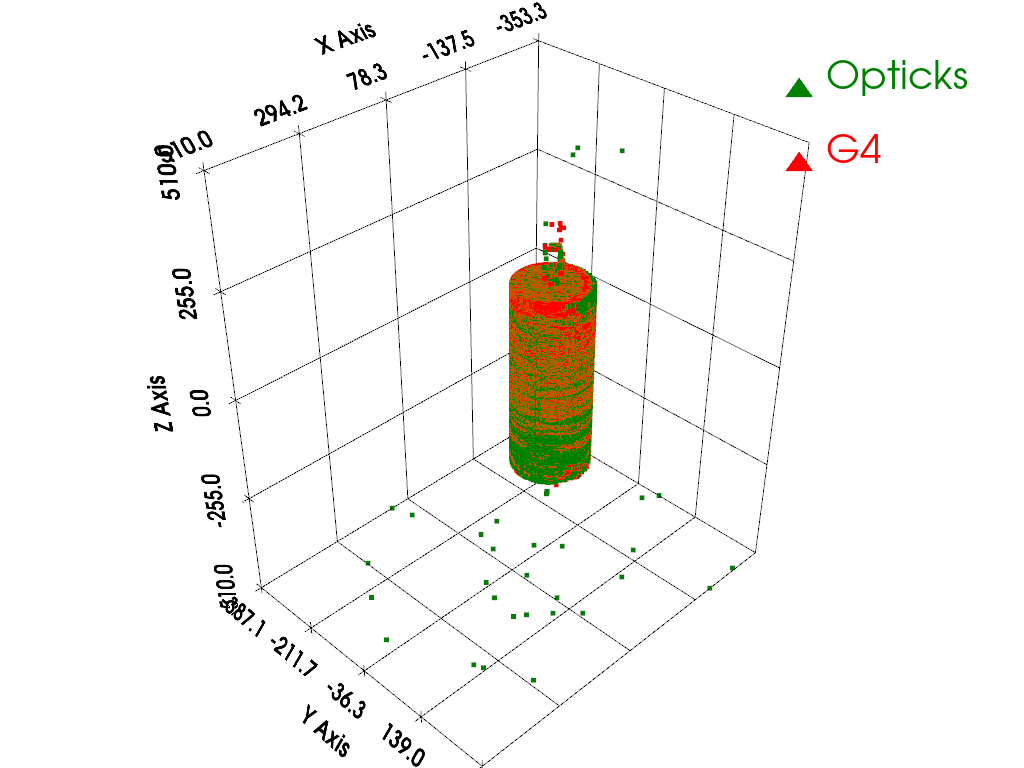

Absorbed Number of Photons
GEANT4 is 3417012 Opticks is 5271464


In [28]:
pl=pv.Plotter()
pl.add_mesh(arrayOpticks_final,color="green",label="Opticks")
pl.add_mesh(arrayG4_final,color="red",label="G4")
pl.show_grid()
pl.add_legend()        
pl.show()
del pl
print("Absorbed Number of Photons")
print(f"GEANT4 is {len(arrayG4_final)} Opticks is {len(arrayOpticks_final)}")

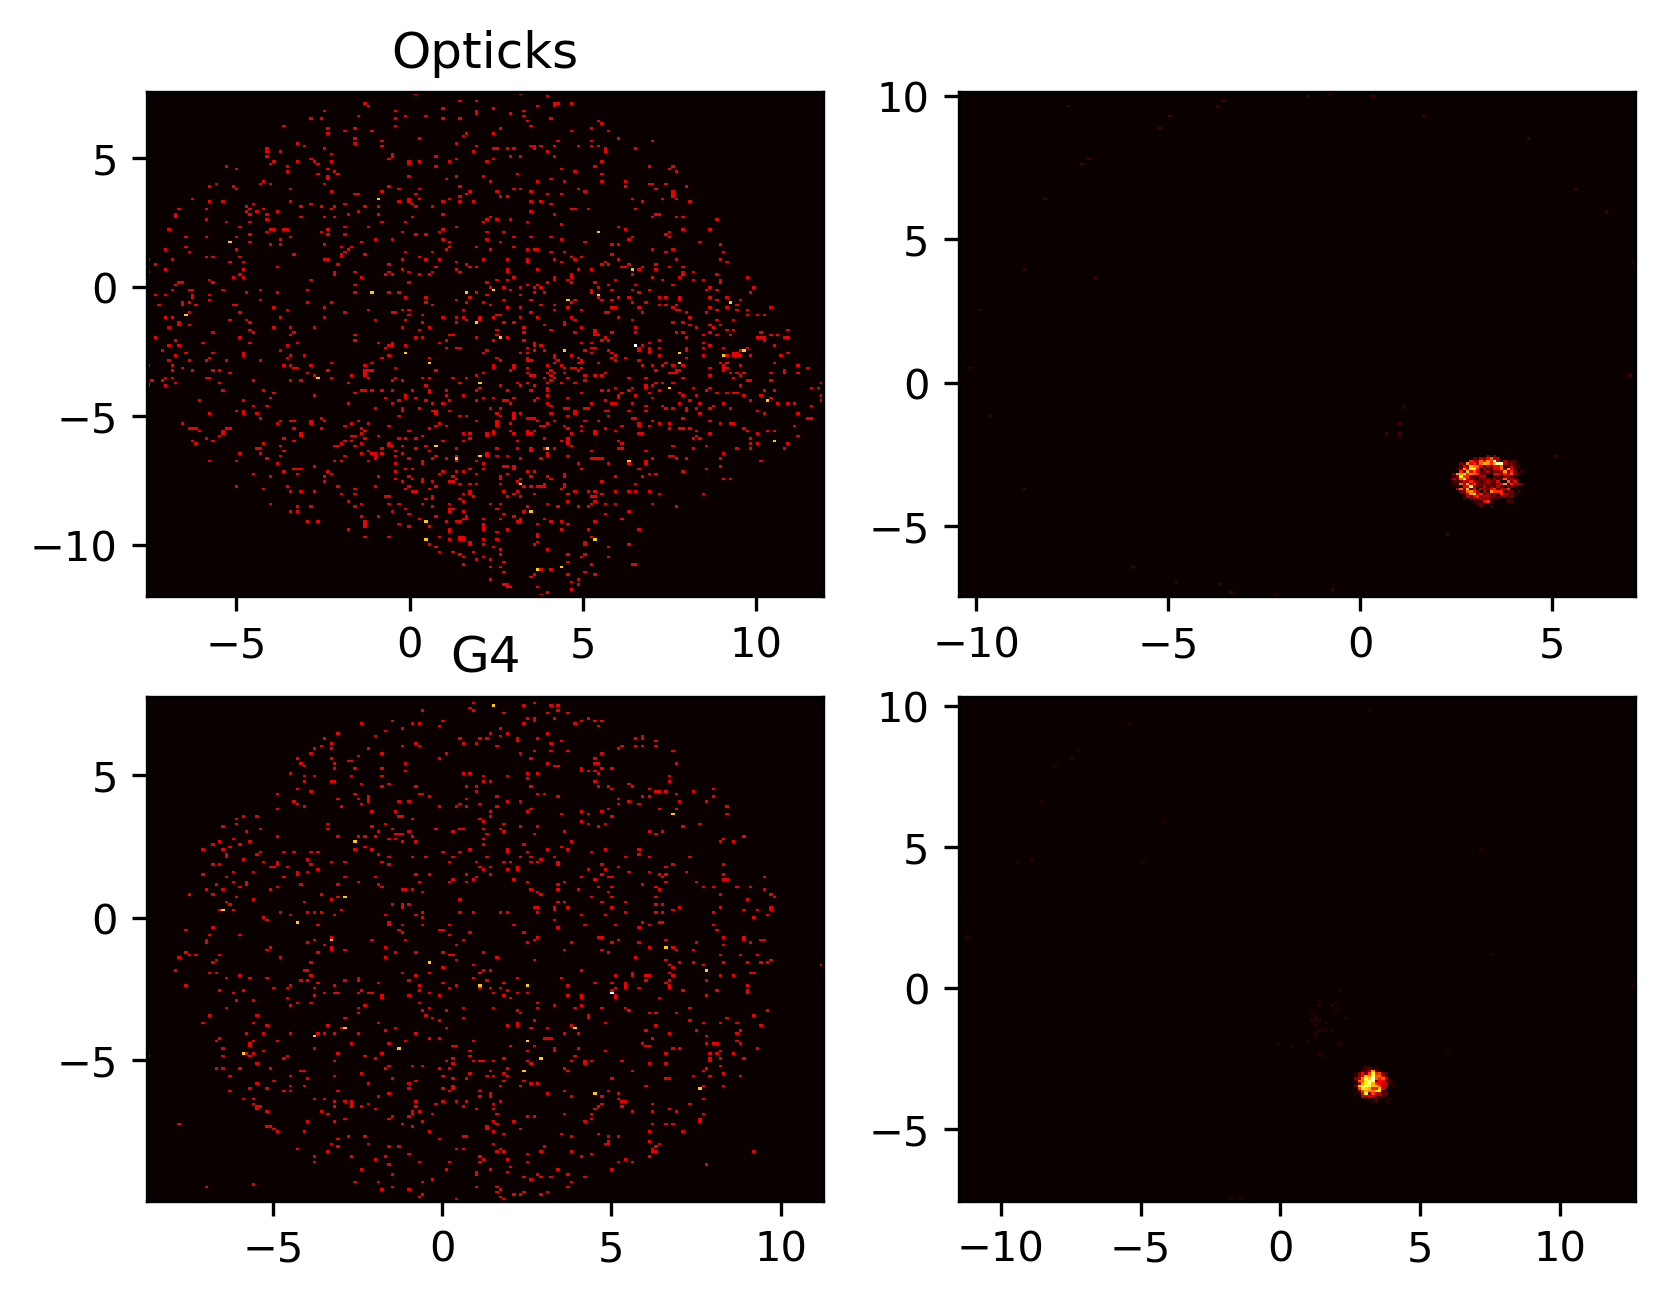

In [29]:
fig,ax=plt.subplots(2,2,dpi=300)
#ax[0,0].hist2d(Hit_Organized["PMT"]["Combined"]["x"],Hit_Organized["PMT"]["Combined"]["y"],bins=200,cmap="hot")
#ax[0,1].hist2d(Hit_Organized["Cam"]["Combined"]["x"], Hit_Organized["Cam"]["Combined"]["y"], bins=200, cmap="hot")
_=ax[0,0].hist2d(OpticksH5Hits["x"][OpticksPMTMask],OpticksH5Hits["y"][OpticksPMTMask],bins=200,cmap="hot")
ax[0,0].set_title("Opticks")
_=ax[0,1].hist2d(OpticksH5Hits["x"][OpticksCamMask], OpticksH5Hits["y"][OpticksCamMask], bins=200, cmap="hot")
ax[1,0].set_title("G4")
_=ax[1,0].hist2d(G4H5Hits["x"][Geant4PMTMask],G4H5Hits["y"][Geant4PMTMask],bins=200,cmap="hot")
_=ax[1,1].hist2d(G4H5Hits["x"][Geant4CamMask],G4H5Hits["y"][Geant4CamMask],bins=200,cmap="hot")


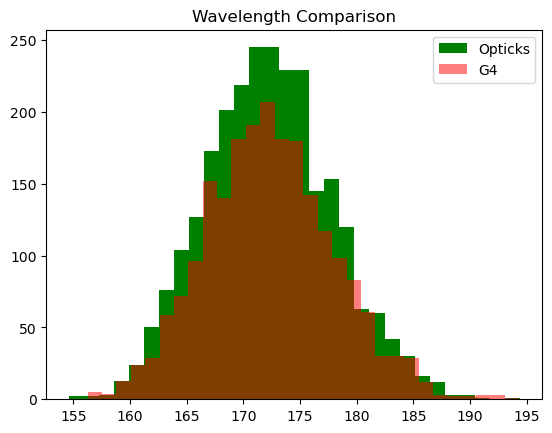

In [30]:
import numpy as np
#Wavelength=np.array([])
#Wavelength=np.append(Hit_Organized["PMT"]["Combined"]["w"],Wavelength)
plt.title("Wavelength Comparison")
#plt.hist(Wavelength,bins=30,color="orange")
plt.hist(OpticksH5Hits["wavelength"], bins=30, color="green",label="Opticks")
plt.hist(G4H5Hits["wavelength"], bins=30, color="red",alpha=0.5,label="G4")
plt.legend()


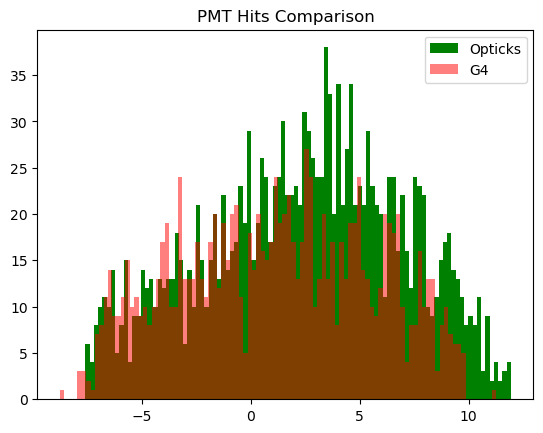

In [31]:
import numpy as np

plt.title("PMT Hits Comparison")
#plt.hist(Hit_Organized["PMT"]["Combined"]["x"], bins=100, color="green",label="Opticks")

plt.hist(OpticksH5Hits["x"][OpticksPMTMask], bins=100, color="green",label="Opticks")
plt.hist(G4H5Hits["x"][Geant4PMTMask], bins=100, color="red",alpha=0.5,label="G4")
plt.legend()

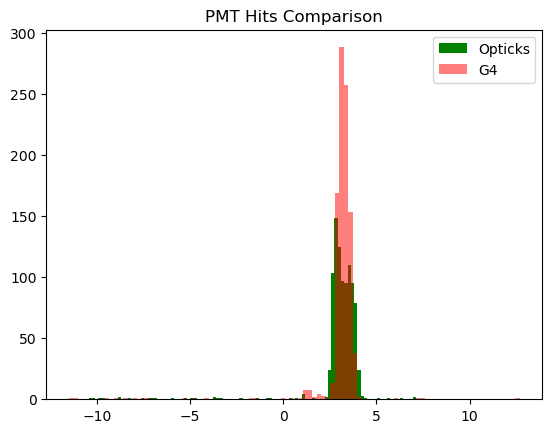

In [32]:
import numpy as np
plt.title("PMT Hits Comparison")
#plt.hist(Hit_Organized["Cam"]["Combined"]["x"], bins=100, color="green",label="Opticks")
plt.hist(OpticksH5Hits["x"][OpticksCamMask], bins=100, color="green",label="Opticks")

plt.hist(G4H5Hits["x"][Geant4CamMask], bins=100, color="red",alpha=0.5,label="G4")
plt.legend()

In [33]:
Hit_Organized["CamHits"]

NameError: name 'Hit_Organized' is not defined

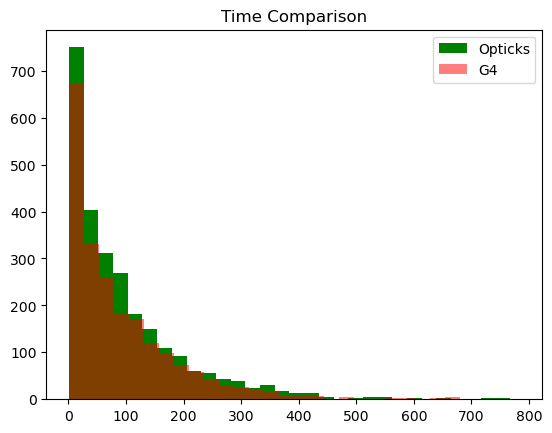

In [34]:
ax[1, 1].hist2d(G4H5Hits["x"][Geant4CamMask], G4H5Hits["y"][Geant4CamMask], bins=200, cmap="hot")
import numpy as np

plt.title("Time Comparison")
plt.hist(OpticksH5Hits["time"], bins=30, color="green", label="Opticks")
plt.hist(G4H5Hits["time"], bins=30, color="red", alpha=0.5, label="G4")
plt.legend()
plt.show()


In [35]:


def getHits(Hits, Mask):
    unique, counts = np.unique(Hits['event_id'][Mask], return_counts=True)
    return counts

Hits G4 [1184],
 Opticks [1650]


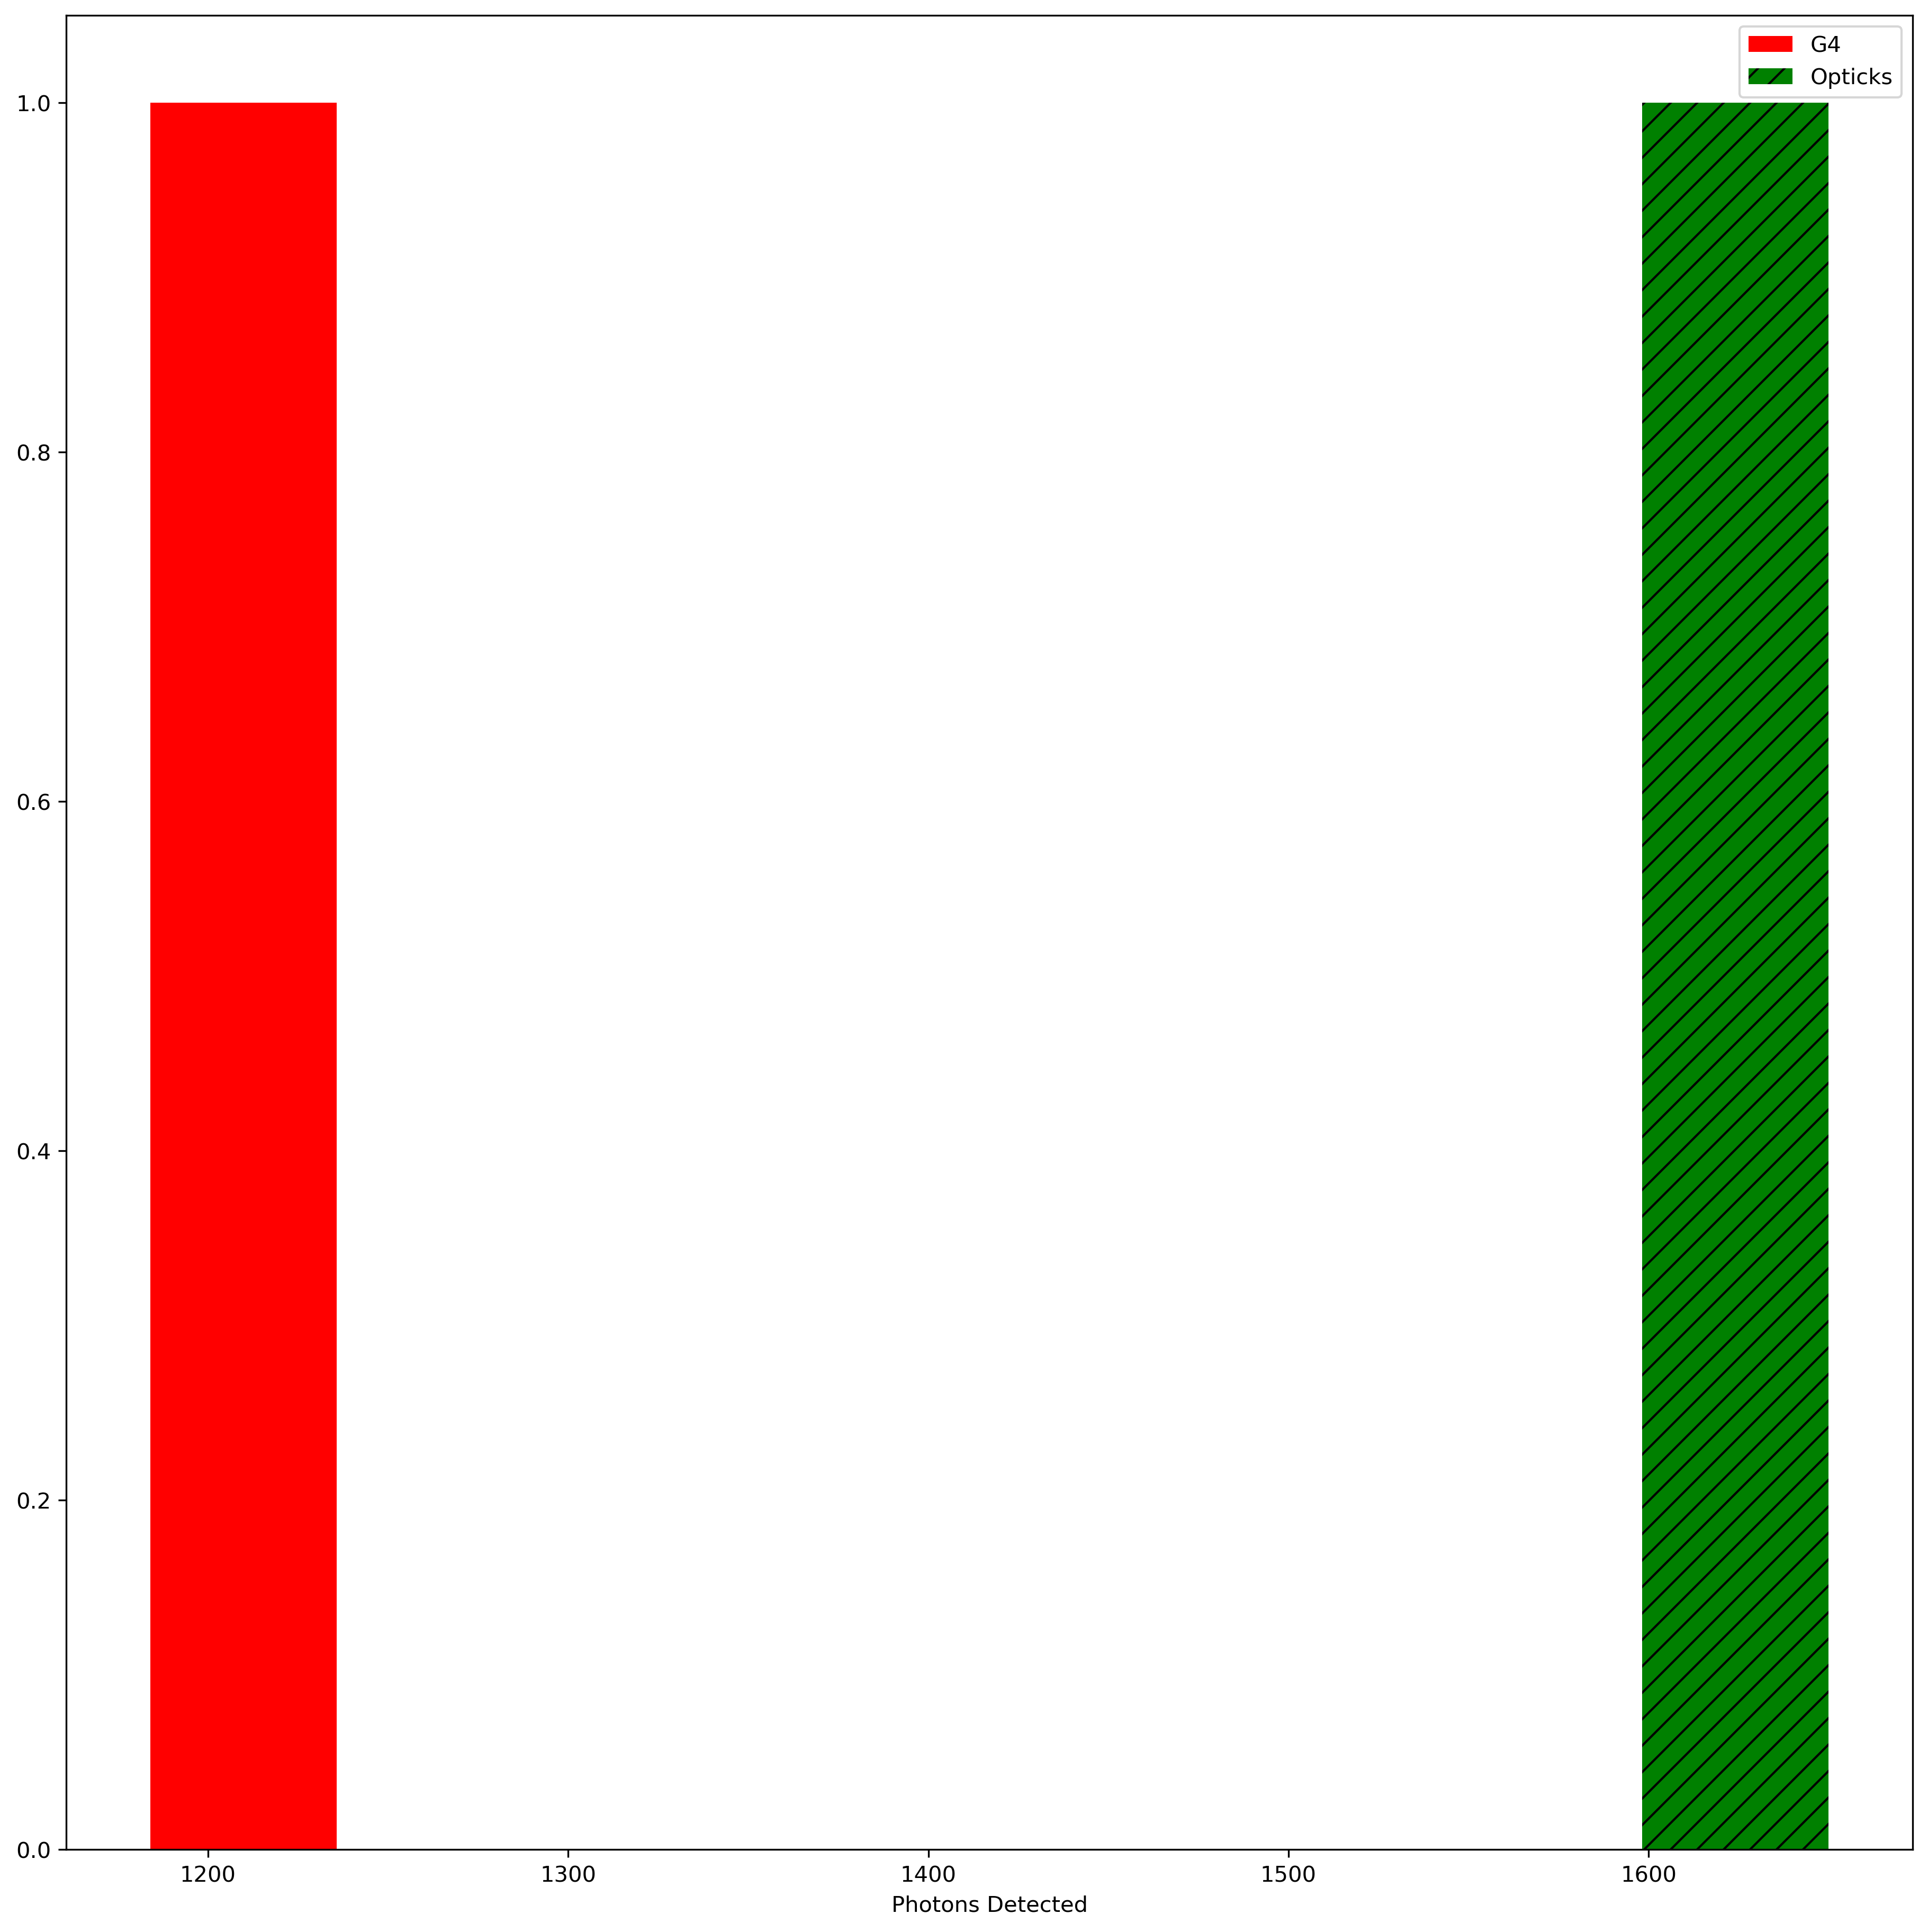

In [36]:
plt.figure(figsize=(15,15),dpi=300)
Binsize=10
G4=getHits(G4H5Hits,Geant4PMTMask)
O=getHits(OpticksH5Hits,OpticksPMTMask)
print(f"Hits G4 {G4},\n Opticks {O}")
maXX=np.max(np.array([np.max(G4),np.max(O)]))
miNX=np.min(np.array([np.min(G4),np.min(O)]))
lins1X=np.linspace(miNX,maXX,Binsize)

h1=plt.hist(G4,bins=lins1X,label="G4",color="red")
#FitHist1D(h1,plt,"Fit","red",0.3)

h2=plt.hist(O,bins=lins1X,label="Opticks",hatch="//",color="green")
#FitHist1D(h2,plt,"Fit","green",0.3)

plt.xlabel("Photons Detected")
plt.legend()
del h1,h2